Executive KPIs

In this section, we calculate the core business metrics requested by the CFO.
All KPIs are generated programmatically to ensure full reproducibility.

Total Net Sales

Total Orders (Distinct InvoiceID)

Total Customers

Average Order Value (AOV)

Total Quantity Sold

Total Profit

Profit Margin %

These KPIs provide a high‑level overview of sales performance, customer activity, and profitability.

In [1]:
# Load Data

In [2]:
import pandas as pd

df   = pd.read_csv("/drive/data/raw/FactSales.csv", parse_dates=["InvoiceDate"])
prod = pd.read_csv("/drive/data/raw/DimProducts.csv")

In [3]:
# --- Cleaning Action 1: Fix missing Category ---
df = df.drop(columns=["Category"]).merge(
    prod[["ProductID", "Category"]], on="ProductID", how="left"
)

# --- Cleaning Action 2: Fix Customer Returns sign ---
returns_mask = df["Quantity"] < 0
df.loc[returns_mask, "NetSales"] = -df.loc[returns_mask, "NetSales"].abs()
df.loc[returns_mask, "Cost"]     = -df.loc[returns_mask, "Cost"].abs()

# --- Derived columns ---
df["Profit"]       = df["NetSales"] - df["Cost"]
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [4]:
# Relative path for reproducibility

In [5]:
# Total Net Sales

In [6]:
df["Profit"] = df["NetSales"] - df["Cost"]

In [7]:
total_net_sales = df["NetSales"].sum()
total_net_sales

np.float64(1896883.7221499435)

In [8]:
# Total Orders (Distinct InvoiceID)

In [9]:
total_orders = df["InvoiceID"].nunique()
total_orders

1500

In [10]:
# Total Customers

In [11]:
total_customers = df["CustomerID"].nunique()
total_customers

100

In [12]:
# Average Order Value (AOV)

In [13]:
average_order_value = total_net_sales / total_orders
average_order_value

np.float64(1264.5891480999624)

In [14]:
# Total Quantity Sold

In [15]:
total_quantity_sold = df["Quantity"].sum()
total_quantity_sold

np.int64(5988)

In [16]:
# Total Profit

In [17]:
total_profit = df["Profit"].sum()
total_profit

np.float64(392009.03724889865)

In [18]:
# Profit Margin %

In [19]:
profit_margin_pct = (total_profit / total_net_sales) * 100
profit_margin_pct

np.float64(20.665949771796893)

In [20]:
# Sales Trend

In [21]:
import matplotlib.pyplot as plt

# Μηνιαία συνάθροιση
monthly = (
    df.groupby("InvoiceMonth")
    .agg(NetSales=("NetSales", "sum"), Profit=("Profit", "sum"))
    .reset_index()
    .sort_values("InvoiceMonth")
)

monthly

,InvoiceMonth,NetSales,Profit
0,2024-01,161187.394742,32855.903093
1,2024-02,150949.195112,29964.467781
2,2024-03,125181.473656,26227.687064
3,2024-04,182219.111690,35112.026577
4,2024-05,140214.649306,31809.281173
5,2024-06,202622.725243,39420.748518
6,2024-07,130013.110434,26825.066299
7,2024-08,179534.425703,37573.728341
8,2024-09,125647.371062,28527.270022
9,2024-10,186762.416496,37463.035099


In [ ]:
# Create Bar Chart 

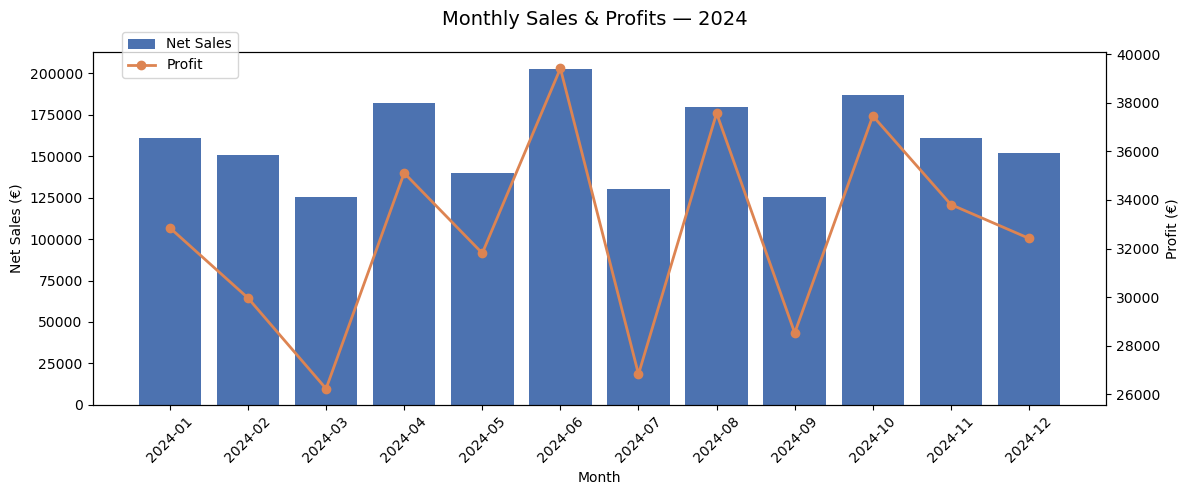

In [24]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Bars = Net Sales 
ax1.bar(monthly["InvoiceMonth"], monthly["NetSales"], 
        color="#4C72B0", label="Net Sales")
ax1.set_ylabel("Net Sales (€)")
ax1.set_xlabel("Month")
ax1.tick_params(axis="x", rotation=45)

# Line = Profit 
ax2 = ax1.twinx()
ax2.plot(monthly["InvoiceMonth"], monthly["Profit"], 
         color="#DD8452", marker="o", linewidth=2, label="Profit")
ax2.set_ylabel("Profit (€)")

# Legend and Title
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
fig.suptitle("Monthly Sales & Profits — 2024", fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:
# Product Analysis

In [26]:
# Top 10 Products by Net Sales
top_10_products = (
    df.groupby("ProductID")
    .agg(NetSales=("NetSales", "sum"), QuantitySold=("Quantity", "sum"))
    .sort_values("NetSales", ascending=False)
    .head(10)
    .reset_index()
)

top_10_products

,ProductID,NetSales,QuantitySold
0,P003,215892.499890,259
1,P008,188472.340663,228
2,P022,167616.510038,197
3,P016,128507.974126,152
4,P028,114915.408857,247
5,P007,112216.525833,136
6,P021,109459.707190,238
7,P027,94910.100894,199
8,P023,93974.165152,204
9,P026,88433.438528,191


In [ ]:
# Add ProductName from DimProducts

In [27]:
top_10_products = (
    df.merge(prod[["ProductID", "ProductName"]], on="ProductID", how="left")
    .groupby(["ProductID", "ProductName"])
    .agg(NetSales=("NetSales", "sum"), QuantitySold=("Quantity", "sum"))
    .sort_values("NetSales", ascending=False)
    .head(10)
    .reset_index()
)

top_10_products

,ProductID,ProductName,NetSales,QuantitySold
0,P003,Product_3,215892.499890,259
1,P008,Product_8,188472.340663,228
2,P022,Product_22,167616.510038,197
3,P016,Product_16,128507.974126,152
4,P028,Product_28,114915.408857,247
5,P007,Product_7,112216.525833,136
6,P021,Product_21,109459.707190,238
7,P027,Product_27,94910.100894,199
8,P023,Product_23,93974.165152,204
9,P026,Product_26,88433.438528,191


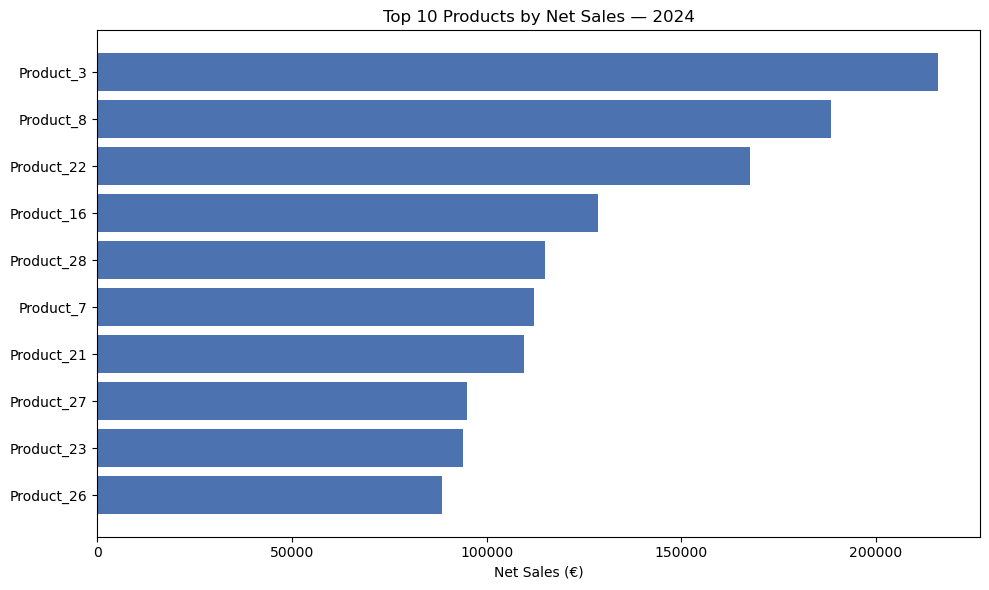

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_10_products["ProductName"], top_10_products["NetSales"], 
        color="#4C72B0")
ax.set_xlabel("Net Sales (€)")
ax.set_title("Top 10 Products by Net Sales — 2024")
ax.invert_yaxis()  # το #1 να είναι πάνω
plt.tight_layout()
plt.show()

In [ ]:
# Revenue by Category

In [29]:
top_categories = (
    df.groupby("Category")["NetSales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_categories

,Category,NetSales
0,Laptops,812705.850550
1,Phones,561612.820356
2,Monitors,451765.054587
3,Accessories,70799.996657


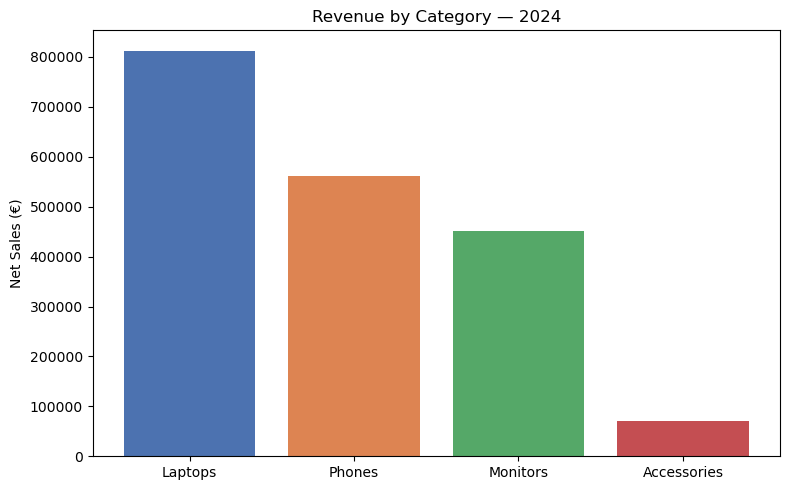

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(top_categories["Category"], top_categories["NetSales"],
       color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_ylabel("Net Sales (€)")
ax.set_title("Revenue by Category — 2024")
plt.tight_layout()
plt.show()

In [ ]:
# Customer Analysis

In [31]:
# Revenue per Customer
revenue_per_customer = (
    df.groupby("CustomerID")
    .agg(NetSales=("NetSales", "sum"), Orders=("InvoiceID", "count"))
    .sort_values("NetSales", ascending=False)
    .reset_index()
)

# Top 10
top_10_customers = revenue_per_customer.head(10)
top_10_customers

,CustomerID,NetSales,Orders
0,C089,38956.179647,21
1,C021,36312.164150,30
2,C032,35421.861729,23
3,C082,32864.611658,19
4,C098,31359.600531,21
5,C099,31276.943585,16
6,C060,31104.385178,28
7,C017,28248.815729,17
8,C008,27198.757896,22
9,C091,27175.138205,11


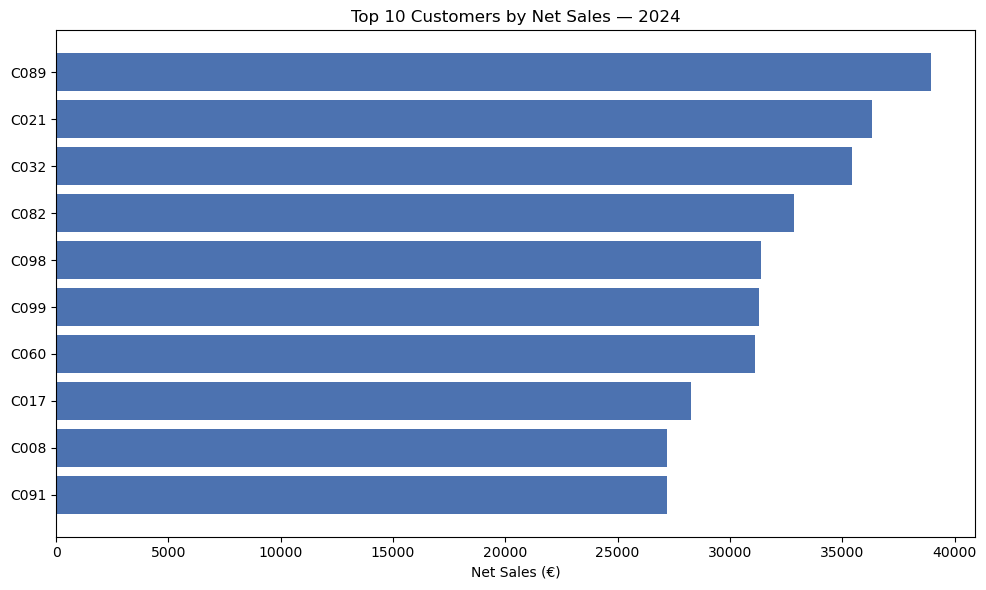

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_10_customers["CustomerID"], top_10_customers["NetSales"],
        color="#4C72B0")
ax.set_xlabel("Net Sales (€)")
ax.set_title("Top 10 Customers by Net Sales — 2024")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [33]:
# Average Revenue per Customer
avg_revenue_per_customer = revenue_per_customer["NetSales"].mean()
print(f"Average Revenue per Customer: €{avg_revenue_per_customer:,.2f}")

Average Revenue per Customer: €18,968.84
